# 03. Python Functions, pandas, and Plotting
@Shengli (Bruce) Jiang, University of South Carolina

This notebook connects Python functions and loops to a reproducible data workflow.

1. Data structures
2. Functions and loops
3. Text file input and output
4. pandas tables and data cleaning
5. Matplotlib plotting

## Running the notebook

Run cells from top to bottom. A later cell may depend on a variable created earlier. When finished, restart the kernel and run all cells to confirm that the notebook is reproducible.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use("default")

## 1. Data Structures

Choose a structure from the job it must do. Lists and tuples store ordered values. Dictionaries attach meaningful labels. NumPy arrays support numerical operations across many values.

### 1.1 Lists and tuples

A list is mutable. A tuple is fixed after creation.

In [2]:
sample = ["run_01", 350, 2.0, True]
sample[1] = 360
sample.append("complete")

print(sample)

['run_01', 360, 2.0, True, 'complete']


In [3]:
experiment = ("run_01", 350, 2.0, True)
name, temperature, pressure, complete = experiment

print(f"name = {name}")
print(f"temperature = {temperature} K")
print(f"pressure = {pressure} bar")
print(f"complete = {complete}")

name = run_01
temperature = 350 K
pressure = 2.0 bar
complete = True


### 1.2 NumPy arrays

An array usually stores one data type. This constraint makes vectorized numerical operations possible.

In [4]:
temperatures_k = np.array([300, 350, 400])
temperatures_k[0] = 310
temperatures_k = temperatures_k + 10

print(temperatures_k)
print(temperatures_k.dtype)

[320 360 410]
int64


Assigning text to an integer array is invalid. The `try` block lets us inspect the error without stopping **Restart and Run All**.

In [5]:
try:
    temperatures_k[0] = "hot"
except ValueError as error:
    print(type(error).__name__ + ":", error)

ValueError: invalid literal for int() with base 10: 'hot'


### 1.3 Dictionaries

A dictionary maps keys to values. Use it when each value needs a meaningful label.

In [6]:
experiment = {
    "name": "run_01",
    "temperature": 350,
    "pressure": [2.0, 3.0, 4.0],
    "complete": True,
}

experiment["temperature"] = 360
experiment["operator"] = "Alex"
experiment["pressure"].append(5.0)

print(experiment["temperature"])
print(experiment["operator"])
print(experiment["pressure"])

360
Alex
[2.0, 3.0, 4.0, 5.0]


In [7]:
print(experiment.keys())
print(experiment.values())
print("name" in experiment)
print(len(experiment))

dict_keys(['name', 'temperature', 'pressure', 'complete', 'operator'])
dict_values(['run_01', 360, [2.0, 3.0, 4.0, 5.0], True, 'Alex'])
True
5


### Data-structure checkpoint

| Structure | Best use | Key feature |
|---|---|---|
| List | Ordered values that may change | Mutable, allows mixed types |
| Tuple | A small fixed record | Immutable, supports unpacking |
| Dictionary | Labeled values | Key-value mapping |
| NumPy array | Numerical data | One data type, vectorized operations |

## 2. Functions and Loops

A function packages reusable instructions. Inputs enter through parameters. A returned value leaves the function for later use.

### 2.1 Return a calculated value

In [8]:
def celsius_to_kelvin(temperature_c):
    '''Convert temperature from degrees Celsius to kelvin.'''
    return temperature_c + 273.15


for temperature_c in [25.0, 100.0]:
    temperature_k = celsius_to_kelvin(temperature_c)
    print(f"{temperature_c:.1f} C is {temperature_k:.2f} K")

25.0 C is 298.15 K
100.0 C is 373.15 K


Without `return`, Python returns `None`. The calculation may occur inside the function, but the result is not available outside it.

In [9]:
def conversion_without_return(temperature_c):
    temperature_c + 273.15


result = conversion_without_return(25.0)
print(result)

None


### 2.2 Use names and a docstring that explain the physical meaning

The function below returns one of three status labels. The order of the tests matters because the shutdown condition is more restrictive than the warning condition.

In [10]:
def reactor_status(temperature_k, pressure_bar):
    '''Classify reactor conditions as normal, warning, or shutdown.'''
    if temperature_k > 500 or pressure_bar > 10:
        return "shutdown"
    if temperature_k > 450 or pressure_bar > 8:
        return "warning"
    return "normal"


conditions = [(420, 6.0), (470, 7.0), (480, 11.0)]
for temperature_k, pressure_bar in conditions:
    print(temperature_k, pressure_bar, reactor_status(temperature_k, pressure_bar))

420 6.0 normal
470 7.0 warning
480 11.0 shutdown


### 2.3 Return multiple results

In [11]:
def summarize_temperature(temperatures):
    minimum = min(temperatures)
    maximum = max(temperatures)
    average = sum(temperatures) / len(temperatures)
    return minimum, maximum, average


minimum, maximum, average = summarize_temperature([300, 350, 400])
print(minimum, maximum, average)

300 400 350.0


A tuple is concise for a small fixed group. A dictionary is clearer when the returned values need names.

In [12]:
def summarize_temperature_named(temperatures):
    return {
        "minimum": min(temperatures),
        "maximum": max(temperatures),
        "average": sum(temperatures) / len(temperatures),
    }


summary = summarize_temperature_named([300, 350, 400])
print(summary)
print(summary["average"])

{'minimum': 300, 'maximum': 400, 'average': 350.0}
350.0


### Try it

Write a function named `pressure_drop` that returns inlet pressure minus outlet pressure. Test it with 8.2 bar and 6.7 bar.

### 2.4 Loops with `range` and `zip`

In [13]:
total = 0

for number in range(1, 4):
    total = total + number
    print(f"number = {number}, total = {total}")

print("range(4) produces", list(range(4)))

number = 1, total = 1
number = 2, total = 3
number = 3, total = 6
range(4) produces [0, 1, 2, 3]


In [14]:
names = ["Run 1", "Run 2", "Run 3"]
temperatures_k = [300, 350, 400]

for name, temperature_k in zip(names, temperatures_k):
    print(f"{name} has temperature {temperature_k} K")

Run 1 has temperature 300 K
Run 2 has temperature 350 K
Run 3 has temperature 400 K


`zip` stops when the shortest sequence ends. Check sequence lengths when every record must be paired.

In [15]:
runs = ["Run 1", "Run 2", "Run 3", "Run 4"]
temperatures_k = [300, 350, 400]
pressures_bar = [1.0, 2.0]

print(list(zip(runs, temperatures_k, pressures_bar)))

[('Run 1', 300, 1.0), ('Run 2', 350, 2.0)]


## 3. Text File Input and Output

Use `with` when opening a file. Python closes the file automatically when the indented block ends.

In [16]:
temperature_file = Path("temperatures.txt")
temperatures_k = [300, 350, 400]

with temperature_file.open("w", encoding="utf-8") as file:
    for temperature_k in temperatures_k:
        file.write(f"{temperature_k}\n")

print("saved", temperature_file.name)

saved temperatures.txt


In [17]:
with temperature_file.open("r", encoding="utf-8") as file:
    content = file.read()

print(content)

300
350
400



## 4. pandas Tables and Data Cleaning

A pandas `DataFrame` stores a labeled table. Rows are observations. Columns are variables.

### 4.1 Build a small table

In [18]:
data = {
    "temperature": [320, 340, 360, 380, 400, 420],
    "time": [1.0, 1.2, 1.4, 1.6, 1.8, 2.0],
    "catalyst": ["A", "A", "B", "B", "C", "C"],
    "conversion": [0.42, 0.55, 0.67, 0.74, 0.81, 0.86],
    "yield": [0.31, 0.44, 0.56, 0.62, 0.65, 0.66],
}

example_df = pd.DataFrame(data)
example_df

,temperature,time,catalyst,conversion,yield
0,320,1.0,A,0.42,0.31
1,340,1.2,A,0.55,0.44
2,360,1.4,B,0.67,0.56
3,380,1.6,B,0.74,0.62
4,400,1.8,C,0.81,0.65
5,420,2.0,C,0.86,0.66


### 4.2 Read the course manufacturing data

In [19]:
data_file = Path("manufacturing_data_with_issues.csv")
if not data_file.exists():
    raise FileNotFoundError(
        "Place manufacturing_data_with_issues.csv in the same folder as this notebook."
    )

df = pd.read_csv(data_file)
df.head()

,Batch ID,Process Date,Reactor Temp C,Pressure bar,Flow Rate L min,Catalyst Type,Defect Count,Conversion Percent,Quality Notes
0,B001,2026-08-01,310,5.2,12.5,A,0.0,94.2,normal run
1,B002,2026-08-02,315,5.4,12.8,A,1.0,92.5,normal run
2,B003,2026-08-03,NaN,5.3,12.7,B,2.0,89.1,missing temperature
3,B004,2026-08-04,999,5.5,13.0,B,8.0,45.0,temperature sensor error
4,B005,2026-08-05,325,NaN,13.1,A,1.0,91.8,missing pressure


### 4.3 Inspect before changing anything

In [20]:
print("shape =", df.shape)
print("columns =", df.columns.tolist())

shape = (22, 9)
columns = ['Batch ID', 'Process Date', 'Reactor Temp C', 'Pressure bar', 'Flow Rate L min', 'Catalyst Type', 'Defect Count', 'Conversion Percent', 'Quality Notes']


In [21]:
df.dtypes

Batch ID                  str
Process Date              str
Reactor Temp C            str
Pressure bar          float64
Flow Rate L min       float64
Catalyst Type             str
Defect Count          float64
Conversion Percent    float64
Quality Notes             str
dtype: object

In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Batch ID            22 non-null     str    
 1   Process Date        22 non-null     str    
 2   Reactor Temp C      21 non-null     str    
 3   Pressure bar        21 non-null     float64
 4   Flow Rate L min     21 non-null     float64
 5   Catalyst Type       21 non-null     str    
 6   Defect Count        21 non-null     float64
 7   Conversion Percent  21 non-null     float64
 8   Quality Notes       22 non-null     str    
dtypes: float64(4), str(5)
memory usage: 1.7 KB


In [23]:
df.describe(include="all")

,Batch ID,Process Date,Reactor Temp C,Pressure bar,Flow Rate L min,Catalyst Type,Defect Count,Conversion Percent,Quality Notes
count,22,22,21,21.000000,21.000000,21,21.000000,21.000000,22
unique,21,21,20,NaN,NaN,4,NaN,NaN,15
top,B015,2026-08-15,375,NaN,NaN,A,NaN,NaN,normal run
freq,2,2,2,NaN,NaN,8,NaN,NaN,8
mean,NaN,NaN,NaN,7.561905,13.761905,NaN,2.904762,81.590476,NaN
std,NaN,NaN,NaN,4.106395,3.845709,NaN,2.447545,15.556700,NaN
min,NaN,NaN,NaN,5.200000,-2.000000,NaN,0.000000,39.800000,NaN
25%,NaN,NaN,NaN,5.900000,13.100000,NaN,1.000000,78.800000,NaN
50%,NaN,NaN,NaN,6.800000,14.600000,NaN,2.000000,85.900000,NaN
75%,NaN,NaN,NaN,7.600000,15.500000,NaN,4.000000,90.400000,NaN


### 4.4 Standardize types and labels

`errors="coerce"` converts unparseable numeric text to `NaN`. Catalyst labels are stripped and converted to uppercase. Dates are parsed one value at a time because the source mixes date formats.

In [24]:
df_work = df.copy()

numeric_columns = [
    "Reactor Temp C",
    "Pressure bar",
    "Flow Rate L min",
    "Defect Count",
    "Conversion Percent",
]

for column in numeric_columns:
    df_work[column] = pd.to_numeric(df_work[column], errors="coerce")

df_work["Process Date"] = df_work["Process Date"].map(
    lambda value: pd.to_datetime(value, errors="coerce")
)

df_work["Catalyst Type"] = (
    df_work["Catalyst Type"]
    .astype("string")
    .str.strip()
    .str.upper()
)

### 4.5 Check duplicates, missing values, and physical ranges

Missing-value handling alone is not enough. A value can be present but physically implausible. The bounds below are teaching assumptions for this example, not universal process limits.

In [25]:
print("duplicate Batch ID values =", df_work.duplicated(subset=["Batch ID"]).sum())
print("\nmissing values before range checks")
print(df_work.isna().sum())

duplicate Batch ID values = 1

missing values before range checks
Batch ID              0
Process Date          0
Reactor Temp C        2
Pressure bar          1
Flow Rate L min       1
Catalyst Type         1
Defect Count          1
Conversion Percent    1
Quality Notes         0
dtype: int64


In [26]:
example_bounds = {
    "Reactor Temp C": (250, 500),
    "Pressure bar": (0, 15),
    "Flow Rate L min": (0, 25),
    "Defect Count": (0, 20),
    "Conversion Percent": (0, 100),
}

invalid_counts = {}
for column, (lower, upper) in example_bounds.items():
    invalid = df_work[column].notna() & ~df_work[column].between(lower, upper)
    invalid_counts[column] = int(invalid.sum())
    df_work.loc[invalid, column] = np.nan

pd.Series(invalid_counts, name="values set to NaN")

Reactor Temp C        1
Pressure bar          1
Flow Rate L min       1
Defect Count          0
Conversion Percent    1
Name: values set to NaN, dtype: int64

Remove duplicate records before calculating imputation values.

In [27]:
df_work = df_work.drop_duplicates(subset=["Batch ID"], keep="first").copy()
print("rows after duplicate removal =", len(df_work))
print(df_work.isna().sum())

rows after duplicate removal = 21
Batch ID              0
Process Date          0
Reactor Temp C        3
Pressure bar          2
Flow Rate L min       2
Catalyst Type         1
Defect Count          1
Conversion Percent    2
Quality Notes         0
dtype: int64


The target is `Conversion Percent`. Rows without a valid target cannot support a target-based analysis, so they are removed. Missing input features are filled with medians. Missing catalyst labels become `Unknown`.

In [28]:
df_clean = df_work.dropna(subset=["Conversion Percent"]).copy()

feature_columns = [
    "Reactor Temp C",
    "Pressure bar",
    "Flow Rate L min",
    "Defect Count",
]

for column in feature_columns:
    df_clean[column] = df_clean[column].fillna(df_clean[column].median())

df_clean["Catalyst Type"] = df_clean["Catalyst Type"].fillna("Unknown")

In [29]:
print("clean shape =", df_clean.shape)
print("remaining missing values =", int(df_clean.isna().sum().sum()))
print("duplicate Batch ID values =", int(df_clean.duplicated(subset=["Batch ID"]).sum()))

for column, (lower, upper) in example_bounds.items():
    assert df_clean[column].between(lower, upper).all()

df_clean.head()

clean shape = (19, 9)
remaining missing values = 0
duplicate Batch ID values = 0


,Batch ID,Process Date,Reactor Temp C,Pressure bar,Flow Rate L min,Catalyst Type,Defect Count,Conversion Percent,Quality Notes
0,B001,2026-08-01,310.0,5.2,12.5,A,0.0,94.2,normal run
1,B002,2026-08-02,315.0,5.4,12.8,A,1.0,92.5,normal run
2,B003,2026-08-03,357.5,5.3,12.7,B,2.0,89.1,missing temperature
3,B004,2026-08-04,357.5,5.5,13.0,B,8.0,45.0,temperature sensor error
4,B005,2026-08-05,325.0,6.5,13.1,A,1.0,91.8,missing pressure


### 4.6 Save the cleaned table and convert selected columns to NumPy

In [30]:
clean_file = Path("manufacturing_data_clean.csv")
df_clean.to_csv(clean_file, index=False)
print("saved", clean_file.name)

saved manufacturing_data_clean.csv


In [31]:
X = df_clean[feature_columns].to_numpy(dtype=float)
y = df_clean["Conversion Percent"].to_numpy(dtype=float)

print("X shape =", X.shape)
print("X dtype =", X.dtype)
print("y shape =", y.shape)
print("first three targets =", y[:3])

X shape = (19, 4)
X dtype = float64
y shape = (19,)
first three targets = [94.2 92.5 89.1]


## 5. Matplotlib Plotting

A figure is the complete canvas. An axes object contains the plotting area, labels, data, and annotations. The object-oriented style makes the target of each command explicit.

### 5.1 One relationship on one axes

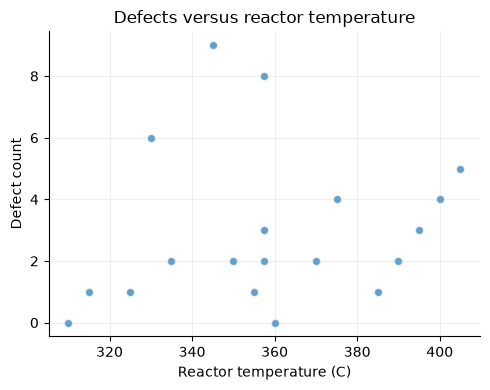

In [32]:
fig, ax = plt.subplots(figsize=(5, 4))

ax.scatter(
    df_clean["Reactor Temp C"],
    df_clean["Defect Count"],
    alpha=0.7,
    edgecolor="white",
)

ax.set_xlabel("Reactor temperature (C)")
ax.set_ylabel("Defect count")
ax.set_title("Defects versus reactor temperature")
ax.grid(alpha=0.2)

for side in ["top", "right"]:
    ax.spines[side].set_visible(False)

fig.tight_layout()
plt.show()

### 5.2 Use a sequential color map for magnitude

Pressure is ordered, so a sequential map such as `viridis` is appropriate.

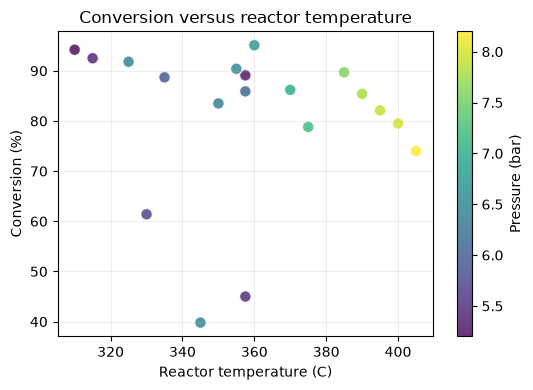

In [33]:
fig, ax = plt.subplots(figsize=(5.5, 4))

points = ax.scatter(
    df_clean["Reactor Temp C"],
    df_clean["Conversion Percent"],
    c=df_clean["Pressure bar"],
    cmap="viridis",
    s=70,
    alpha=0.8,
    edgecolor="white",
)

ax.set_xlabel("Reactor temperature (C)")
ax.set_ylabel("Conversion (%)")
ax.set_title("Conversion versus reactor temperature")
ax.grid(alpha=0.2)

colorbar = fig.colorbar(points, ax=ax)
colorbar.set_label("Pressure (bar)")

fig.tight_layout()
plt.show()

### 5.3 Use category labels and marker shape for identity

Color should not carry the entire explanation. The plot below uses both color and marker shape for catalyst identity.

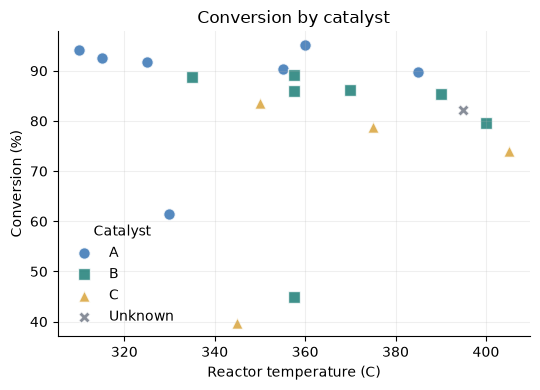

In [34]:
palette = {
    "A": "#2B6CB0",
    "B": "#0F766E",
    "C": "#D69E2E",
    "Unknown": "#6B7280",
}
markers = {"A": "o", "B": "s", "C": "^", "Unknown": "X"}

fig, ax = plt.subplots(figsize=(5.5, 4))

for catalyst, group in df_clean.groupby("Catalyst Type", sort=True):
    ax.scatter(
        group["Reactor Temp C"],
        group["Conversion Percent"],
        label=catalyst,
        color=palette.get(catalyst, "#6B7280"),
        marker=markers.get(catalyst, "o"),
        s=70,
        alpha=0.8,
        edgecolor="white",
    )

ax.set_xlabel("Reactor temperature (C)")
ax.set_ylabel("Conversion (%)")
ax.set_title("Conversion by catalyst")
ax.grid(alpha=0.2)
ax.legend(title="Catalyst", frameon=False)

for side in ["top", "right"]:
    ax.spines[side].set_visible(False)

fig.tight_layout()
plt.show()